### AND Gate using MCP Neuron
AND is TRUE only when **both** inputs are 1.  
So we need the sum to reach **T = 2** (both inputs must fire).

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND logic using an MCP Neuron.

    How it works:
      - Add X1[i] + X2[i] for each position  (element-wise sum)
      - If the sum >= T  →  neuron fires  → output 1
      - If the sum <  T  →  neuron silent → output 0
      - For AND: T = 2  (both inputs must be 1)

    Parameters:
      X1 (list): Binary input array
      X2 (list): Binary input array
      T  (int) : Threshold

    Returns:
      state_neuron (list): Output 1 or 0 for each input pair
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise sum of the two input arrays
    input_sum = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold — fire (1) if sum >= T, else silent (0)
    state_neuron = []
    for s in input_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# --- AND Gate Test ---
# Truth table: AND is 1 only when BOTH inputs are 1
#  X1=0, X2=0 → 0+0=0 < 2 → 0
#  X1=0, X2=1 → 0+1=1 < 2 → 0
#  X1=1, X2=0 → 1+0=1 < 2 → 0
#  X1=1, X2=1 → 1+1=2 >= 2 → 1

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # Threshold for AND gate

result = MCP_Neurons_AND(X1, X2, T)
print(f'Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}')
# Expected: [0, 0, 0, 1]

### OR Gate using MCP Neuron
OR is TRUE when **at least one** input is 1.  
So we need the sum to reach **T = 1** (at least one input must fire).

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR logic using an MCP Neuron.

    How it works:
      - Same structure as AND, but with T = 1
      - OR fires whenever at least one input is 1 (sum >= 1)

    Parameters:
      X1 (list): Binary input array
      X2 (list): Binary input array
      T  (int) : Threshold

    Returns:
      state_neuron (list): Output 1 or 0 for each input pair
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise sum
    input_sum = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold
    state_neuron = []
    for s in input_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# --- OR Gate Test ---
# Truth table: OR is 1 when AT LEAST ONE input is 1
#  X1=0, X2=0 → 0+0=0 < 1 → 0
#  X1=0, X2=1 → 0+1=1 >= 1 → 1
#  X1=1, X2=0 → 1+0=1 >= 1 → 1
#  X1=1, X2=1 → 1+1=2 >= 1 → 1

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # Threshold for OR gate

result_or = MCP_Neurons_OR(X1, X2, T)
print(f'Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}')
# Expected: [0, 1, 1, 1]

### Step 1 — Load the Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
# If running in Google Colab, upload the file first then use:
#   df_0_1 = pd.read_csv('/content/mnist_0_and_1.csv')
# If running locally, use the path below:
df_0_1 = pd.read_csv('/content/mnist_0_and_1.csv')

# Extract features and labels
X = df_0_1.drop(columns=['label']).values   # shape: (12665, 784)
y = df_0_1['label'].values                  # shape: (12665,)  — values are 0 or 1

print('Feature matrix shape:', X.shape)     # (12665, 784)
print('Label vector shape:  ', y.shape)     # (12665,)
print('Classes present:     ', np.unique(y))

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)
Classes present:      [0 1]


### Viewing the Dataset — 5 examples each of digit 0 and digit 1

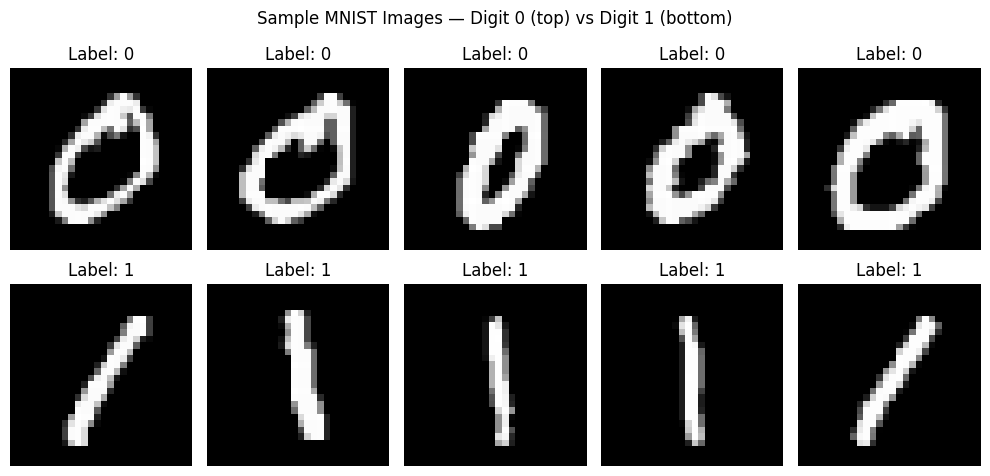

In [5]:
# Separate images by label
images_0 = X[y == 0]   # all digit-0 images
images_1 = X[y == 1]   # all digit-1 images

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    # Top row: digit 0
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title('Label: 0')
    axes[0, i].axis('off')

    # Bottom row: digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Label: 1')
    axes[1, i].axis('off')

plt.suptitle('Sample MNIST Images — Digit 0 (top) vs Digit 1 (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

### Step 2 — Initialise Weights

In [6]:
# Initialise weights (one per pixel) and bias to zero
weights       = np.zeros(X.shape[1])   # shape: (784,) — all zeros to start
bias          = 0
learning_rate = 0.1
epochs        = 100

print(f'Weights shape : {weights.shape}')
print(f'Bias          : {bias}')
print(f'Learning rate : {learning_rate}')
print(f'Epochs        : {epochs}')

Weights shape : (784,)
Bias          : 0
Learning rate : 0.1
Epochs        : 100
